<a href="https://colab.research.google.com/github/sneghaganesh3-rgb/Yolo_mask_Attendance_System/blob/main/dp_pro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="IQy4PyB8Lbky9u7Xu3vY")
project = rf.workspace("basel-zqu2o").project("face-mask-detection-wuofg")
version = project.version(3)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 90.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Face-Mask-Detection.-3 in yolov8:: 100%|██████████| 1760/1760 [00:00<00:00, 8464.26it/s]


In [ ]:
import os

dataset_path = "/content/Face-Mask-Detection.-3"

print("Dataset folders:")
print(os.listdir(dataset_path))

Dataset folders:
['test', 'train', 'valid', 'README.dataset.txt', 'data.yaml', 'README.roboflow.txt']


In [ ]:
train_images = len(os.listdir(dataset_path + "/train/images"))
val_images = len(os.listdir(dataset_path + "/valid/images"))
test_images = len(os.listdir(dataset_path + "/test/images"))

print("Dataset Split:")
print("Train Images:", train_images)
print("Validation Images:", val_images)
print("Test Images:", test_images)

Dataset Split:
Train Images: 673
Validation Images: 139
Test Images: 62


In [ ]:
import yaml

with open(dataset_path + "/data.yaml", 'r') as file:
    data = yaml.safe_load(file)

print("Number of Classes:", data['nc'])
print("Class Names:", data['names'])

Number of Classes: 2
Class Names: ['Mask', 'No Mask']


In [ ]:
from collections import defaultdict

label_path = dataset_path + "/train/labels"

class_counts = defaultdict(int)

for file in os.listdir(label_path):

    with open(os.path.join(label_path, file), "r") as f:
        lines = f.readlines()

        for line in lines:
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

print("Class Distribution:")

for i, name in enumerate(data['names']):
    print(name, ":", class_counts[i])

Class Distribution:
Mask : 4567
No Mask : 165


In [ ]:
!pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 35.7 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
from roboflow import Roboflow
import os
model = YOLO("yolov8n.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model.train(
    data="/content/Face-Mask-Detection.-3/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    name="mask_detector"
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Face-Mask-Detection.-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=mask_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78403e0ff1d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
metrics = model.val()

print("Precision:", metrics.results_dict['metrics/precision(B)'])
print("Recall:", metrics.results_dict['metrics/recall(B)'])
print("mAP50:", metrics.results_dict['metrics/mAP50(B)'])
print("mAP50-95:", metrics.results_dict['metrics/mAP50-95(B)'])

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1551.3±379.6 MB/s, size: 51.7 KB)
val: Scanning /content/Face-Mask-Detection.-3/valid/labels.cache... 139 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 139/139 58.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.9it/s 4.7s
                   all        139        868       0.71      0.648      0.723      0.515
                  Mask        125        841      0.865      0.592      0.724      0.433
               No Mask         26         27      0.555      0.704      0.723      0.597
Speed: 4.8ms preprocess, 6.5ms inference, 0.1ms loss, 4.7ms postprocess per image
Results saved to /content/runs/detect/val
Precision: 0.7099489005662525
Recall: 0.6479385481525828
mAP50: 0.7232689386213655
mAP50-9

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/mask_detector/weights/best.pt")

In [ ]:
results = model.predict(
    source="/content/Face-Mask-Detection.-3/test/images",
    conf=0.25,
    save=True
)


image 1/62 /content/Face-Mask-Detection.-3/test/images/maksssksksss482_png.rf.7308c9e450bb79a2d40b707109df3d69.jpg: 640x640 1 No Mask, 10.3ms
image 2/62 /content/Face-Mask-Detection.-3/test/images/maksssksksss485_png.rf.02039984ecfb20483631fa006b2be01f.jpg: 640x640 1 Mask, 7.2ms
image 3/62 /content/Face-Mask-Detection.-3/test/images/maksssksksss501_png.rf.4c916cba455046b0b17320aa119a19c7.jpg: 640x640 9 Masks, 7.2ms
image 4/62 /content/Face-Mask-Detection.-3/test/images/maksssksksss503_png.rf.a2c4cdad60addf52592259dd0f9baa8b.jpg: 640x640 2 Masks, 7.2ms
image 5/62 /content/Face-Mask-Detection.-3/test/images/maksssksksss50_png.rf.2fa51db748816389135bafbeb565fe24.jpg: 640x640 2 Masks, 7.2ms
image 6/62 /content/Face-Mask-Detection.-3/test/images/maksssksksss527_png.rf.cfc6663eb39c543d79c468bcbb18b006.jpg: 640x640 16 Masks, 7.2ms
image 7/62 /content/Face-Mask-Detection.-3/test/images/maksssksksss531_png.rf.0e62d6af47a5199b56e4e8134f64e04a.jpg: 640x640 1 Mask, 7.2ms
image 8/62 /content/Face-

In [ ]:
import os

test_images_path = "/content/Face-Mask-Detection.-3/test/images"

images = os.listdir(test_images_path)

# Select first 10 images
sample_images = images[:10]

sample_images


['maksssksksss771_png.rf.3e83a9107a2077c77bf9b3dd8128d9ee.jpg',
 'maksssksksss71_png.rf.f195a21e1478f13bed1c6a08f219c529.jpg',
 'maksssksksss562_png.rf.48c4cd1406406279ec5dbb099af90524.jpg',
 'maksssksksss694_png.rf.12673f940e12d860cfd9220c96fd4c30.jpg',
 'maksssksksss808_png.rf.a1fd2884d6f83a11a08e9590b64bbbfd.jpg',
 'maksssksksss725_png.rf.4adf13feb310d41840e074d0824e8f98.jpg',
 'maksssksksss630_png.rf.c4ebc605d0e78ccda3aff4b591387ded.jpg',
 'maksssksksss9_png.rf.1c2beb5d45b8814a07c4e93d841561e6.jpg',
 'maksssksksss545_png.rf.3e0c5d064fd3ae8d88efceb891a6bdbd.jpg',
 'maksssksksss556_png.rf.8c9b170ee9fa90e91bffca28f78dad5f.jpg']

In [ ]:
results = model.predict(
    source=[os.path.join(test_images_path, img) for img in sample_images],
    conf=0.25,
    save=True
)


0: 640x640 9 Masks, 6.1ms
1: 640x640 8 Masks, 6.1ms
2: 640x640 1 Mask, 1 No Mask, 6.1ms
3: 640x640 5 Masks, 6.1ms
4: 640x640 1 Mask, 6.1ms
5: 640x640 1 Mask, 6.1ms
6: 640x640 1 Mask, 6.1ms
7: 640x640 2 Masks, 1 No Mask, 6.1ms
8: 640x640 20 Masks, 6.1ms
9: 640x640 23 Masks, 6.1ms
Speed: 2.4ms preprocess, 6.1ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


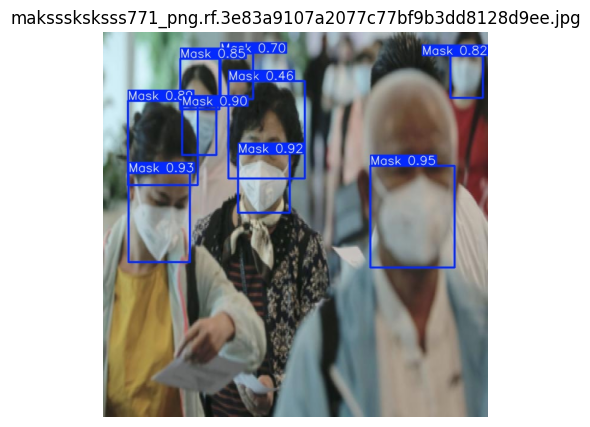

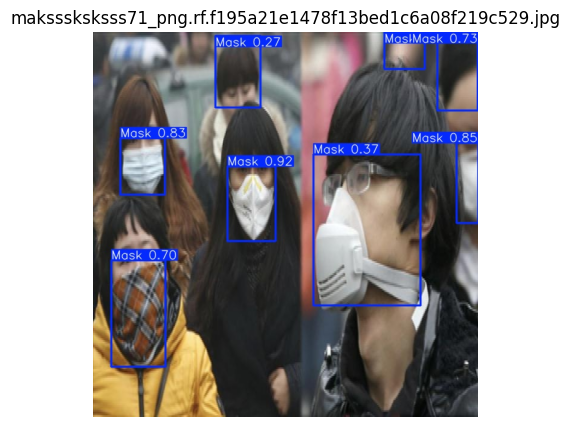

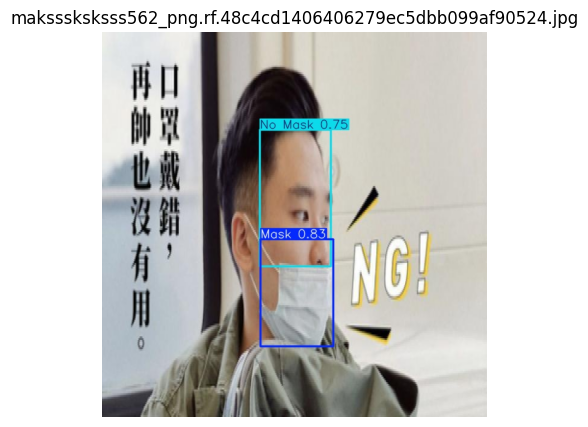

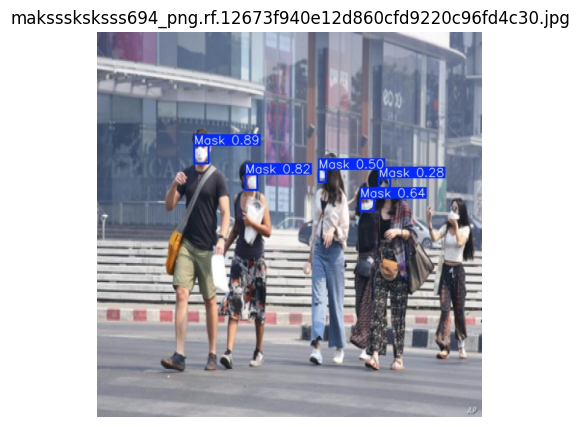

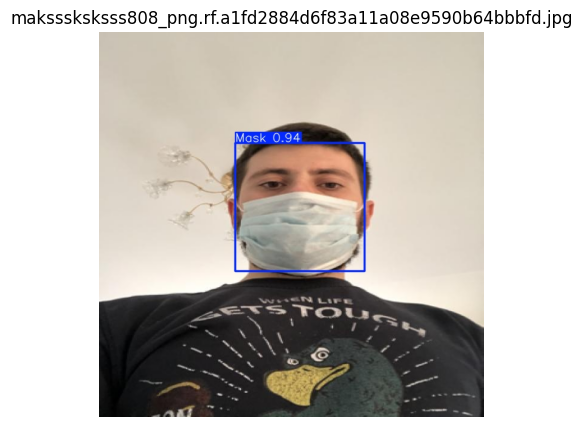

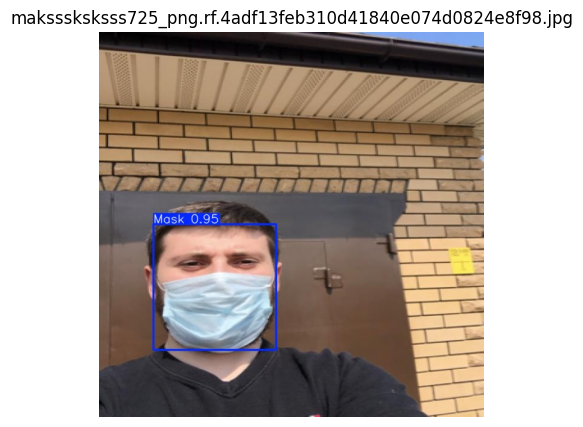

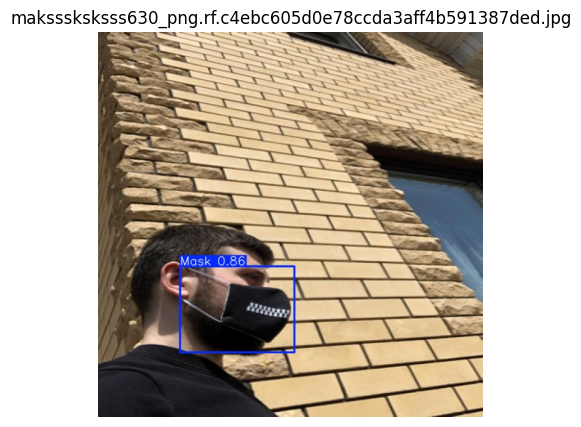

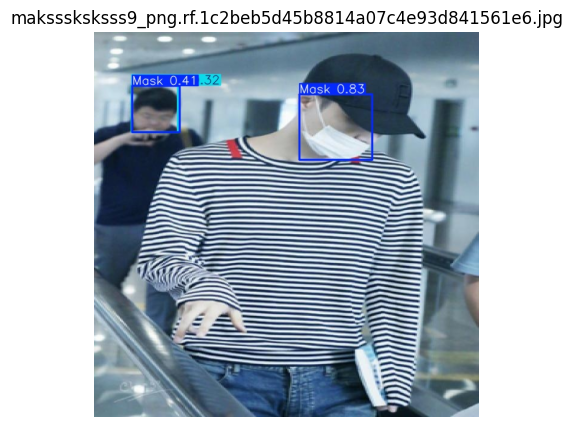

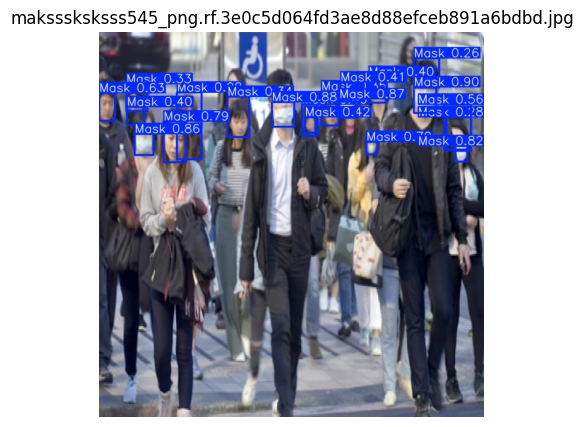

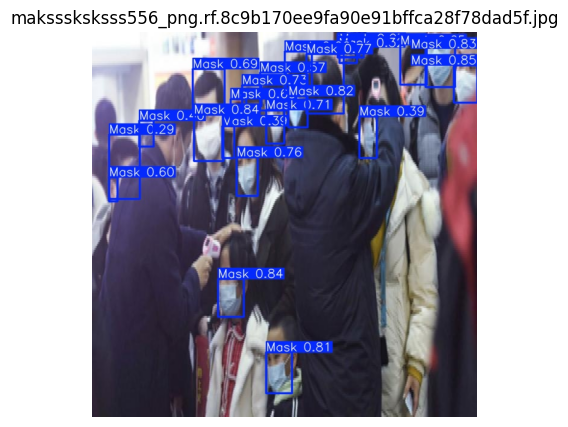

In [ ]:
import cv2
import matplotlib.pyplot as plt

predict_folder = "/content/runs/detect/predict"

pred_images = os.listdir(predict_folder)

for img in pred_images[:10]:

    img_path = os.path.join(predict_folder, img)

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(5,5))
    plt.imshow(image)
    plt.title(img)
    plt.axis("off")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = "/content/drive/MyDrive/YOLOv8_Mask_Attendance_System"

os.makedirs(project_path, exist_ok=True)

print("Project folder created:", project_path)

Project folder created: /content/drive/MyDrive/YOLOv8_Mask_Attendance_System


In [ ]:
folders = [
    "dataset",
    "models",
    "predictions",
    "results",
    "notebooks",
    "scripts"
]

for folder in folders:
    os.makedirs(os.path.join(project_path, folder), exist_ok=True)

print("All folders created successfully")

All folders created successfully


In [ ]:
!cp -r /content/Face-Mask-Detection.-3 $project_path/dataset

In [ ]:
!cp /content/runs/detect/mask_detector/weights/best.pt $project_path/models/

In [ ]:
!cp -r /content/runs/detect/predict $project_path/predictions

In [ ]:
!cp -r /content/runs/detect/mask_detector $project_path/results

In [ ]:
!ls /content/drive/MyDrive/YOLOv8_Mask_Attendance_System

dataset  models  notebooks  predictions  results  scripts


Opening Webcam...
Image Captured

image 1/1 /content/photo.jpg: 480x640 1 No Mask, 76.4ms
Speed: 11.1ms preprocess, 76.4ms inference, 36.4ms postprocess per image at shape (1, 3, 480, 640)


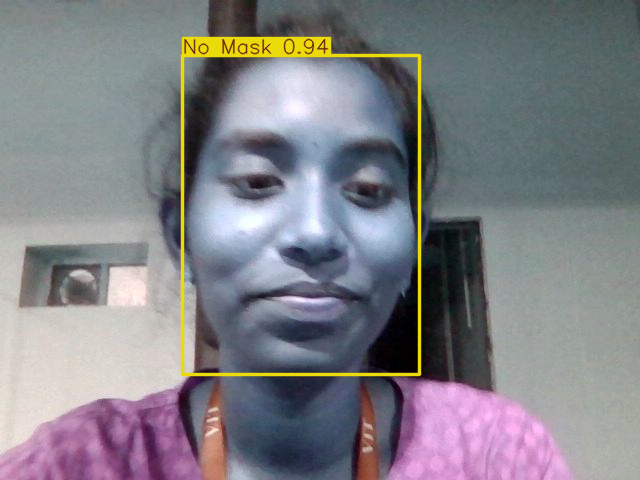

🔴 RED SIGNAL - GATE CLOSED
Press ENTER to scan again or type q to quit: 
Opening Webcam...
Image Captured

image 1/1 /content/photo.jpg: 480x640 1 Mask, 8.9ms
Speed: 2.2ms preprocess, 8.9ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


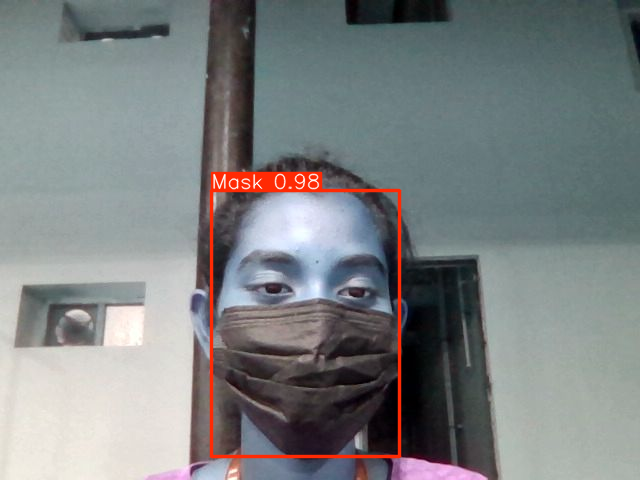

🟢 GREEN SIGNAL - GATE OPEN
Press ENTER to scan again or type q to quit: 
Opening Webcam...
Image Captured

image 1/1 /content/photo.jpg: 480x640 1 No Mask, 28.2ms
Speed: 2.9ms preprocess, 28.2ms inference, 2.5ms postprocess per image at shape (1, 3, 480, 640)


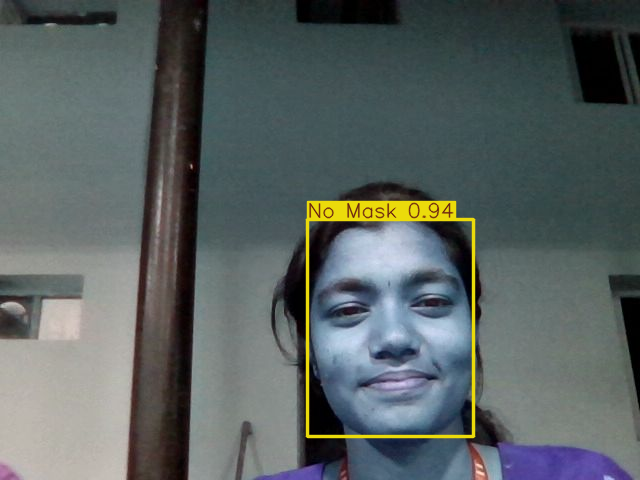

🔴 RED SIGNAL - GATE CLOSED
Press ENTER to scan again or type q to quit: 
Opening Webcam...
Image Captured

image 1/1 /content/photo.jpg: 480x640 1 Mask, 8.9ms
Speed: 2.1ms preprocess, 8.9ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)


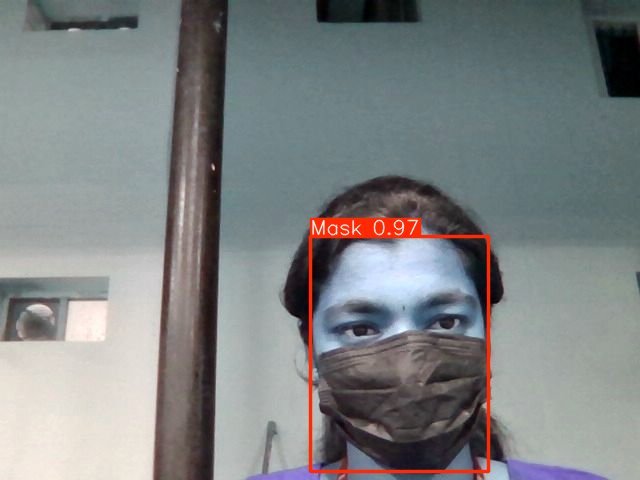

🟢 GREEN SIGNAL - GATE OPEN
Press ENTER to scan again or type q to quit: 
Opening Webcam...
Image Captured

image 1/1 /content/photo.jpg: 480x640 1 Mask, 2 No Masks, 24.0ms
Speed: 1.9ms preprocess, 24.0ms inference, 5.9ms postprocess per image at shape (1, 3, 480, 640)


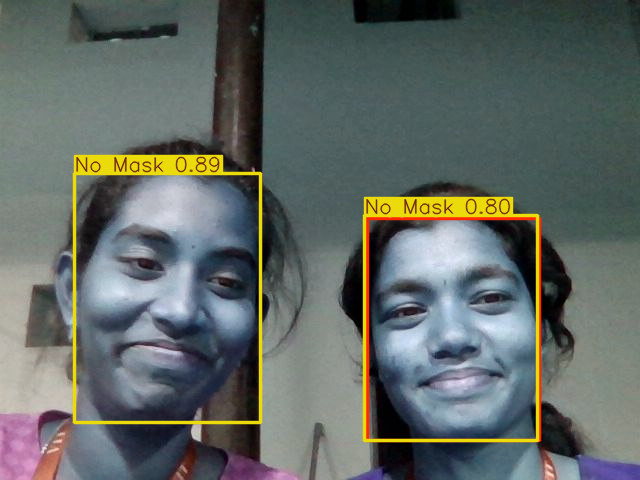

🔴 RED SIGNAL - GATE CLOSED
🔴 RED SIGNAL - GATE CLOSED
🟢 GREEN SIGNAL - GATE OPEN
Press ENTER to scan again or type q to quit: 
Opening Webcam...


In [ ]:

!pip install ultralytics opencv-python pillow

from ultralytics import YOLO
import cv2
import numpy as np
from google.colab import output
from base64 import b64decode
from PIL import Image
from IPython.display import display

model = YOLO("/content/drive/MyDrive/YOLOv8_Mask_Attendance_System/models/best.pt")

def capture_image(filename='photo.jpg'):

    js = """
    async function capture() {
        const video = document.createElement('video');
        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        document.body.appendChild(video);
        video.srcObject = stream;
        await video.play();

        await new Promise(resolve => setTimeout(resolve, 3000));

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        canvas.getContext('2d').drawImage(video, 0, 0);

        stream.getTracks()[0].stop();
        video.remove();

        return canvas.toDataURL('image/jpeg', 0.8);
    }
    capture();
    """

    data = output.eval_js(js)
    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename


while True:

    print("Opening Webcam...")

    img_path = capture_image()

    print("Image Captured")

    results = model(img_path)

    annotated = results[0].plot()

    img = Image.fromarray(annotated)

    display(img)

    for r in results:
        boxes = r.boxes

        if boxes is not None:

            for box in boxes:

                cls = int(box.cls)
                label = model.names[cls]

                if label.lower() == "mask":

                    print("🟢 GREEN SIGNAL - GATE OPEN")

                else:

                    print("🔴 RED SIGNAL - GATE CLOSED")

    choice = input("Press ENTER to scan again or type q to quit: ")

    if choice == "q":
        break